# Plotnine and 1D density

## Introduction

While surfing the web, I came across a graphic produced by ggplot2 in R, and I wondered if I could replicate it in __plotnine__ and Python.

The ovetall graphic shows a row of tall thing graphics, each a different visualization of the density of a set of points on a line.  I chose a bi-modal two-Gaussian dataset to visualize.  To get my tall, thin plots, in most cases I rotate my first-pass graphic, which I create with the minimal code possible

------------------------

## Implementation

### Imports

-  numpy handle numerical cxomputing
-  pandas handles dataframes
-  plotnine does all the plotting
-  warnings can be used to supress usere warning from plotnine

In [1]:
import warnings

import numpy as np
import pandas as pd
import plotnine as p9

### Magics

watermark produces reproducability information

In [2]:
%load_ext watermark

### Create dataset

We get 2000 points, 1000 each from two different Gaussians, and create a pandas DataFrame. The __fill__ column holds the text name of our desired fill color (if fill is supported by the graphic style)

In [3]:
size = 1000
x = list(np.random.normal(-2, 1, size)) + list(np.random.normal(2, 1, size))

In [4]:
df = pd.DataFrame({"x": x, "fill": ["white"] * (2 * size)})

--------------------------------

## Graphics

### Point plot

The first approach is to plot the data points as graphic points, with a very high transparency (low alpha).  The overlapping points show the density of the dataset.  We will label every plotnine plot with a descriptive subtitle.  Every plot will have a black&white theme

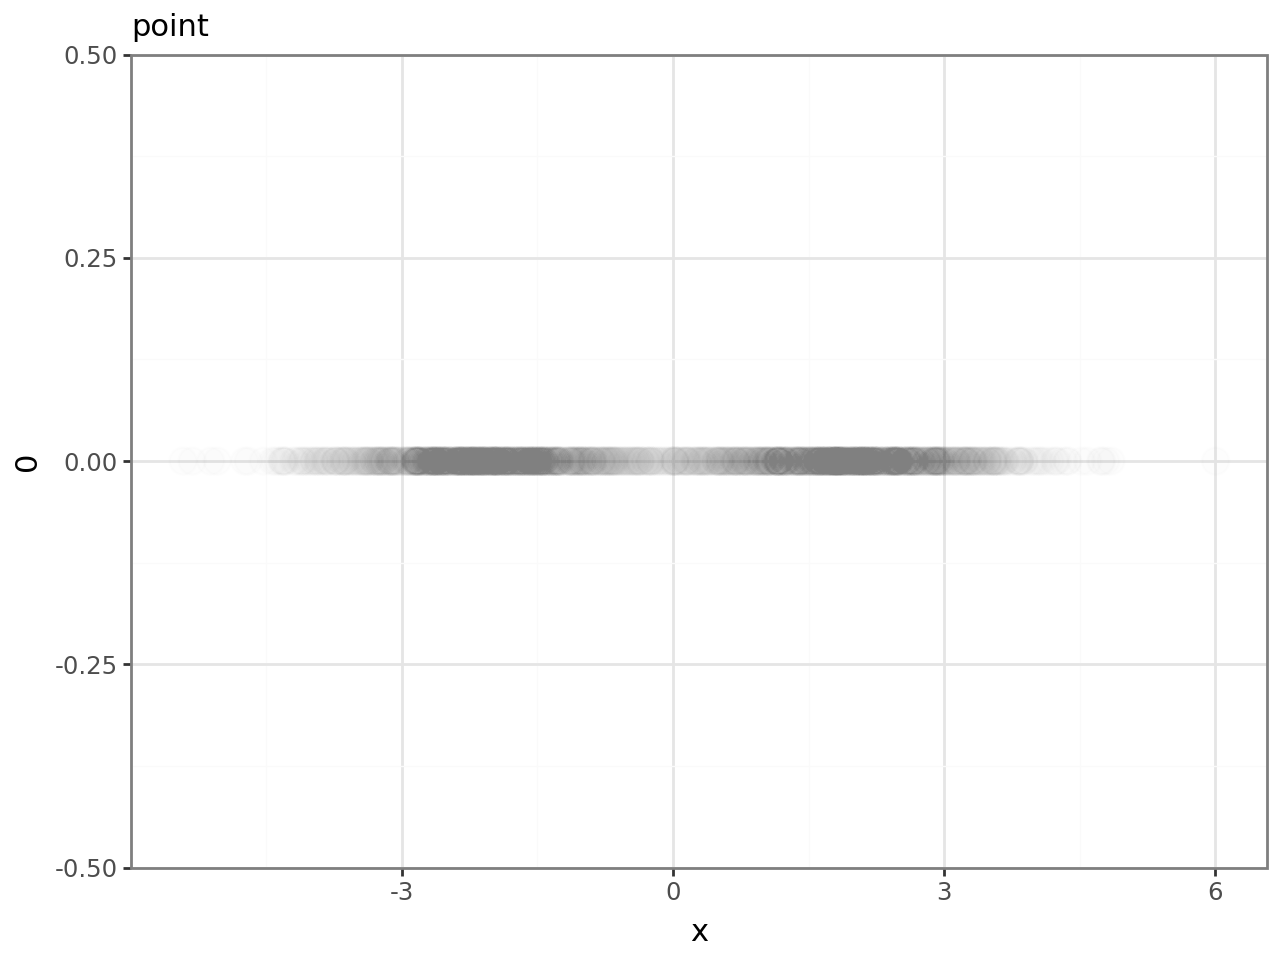

In [5]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_point(
        mapping=p9.aes(x="x", y=0),
        color="gray",
        alpha=0.01,
        size=5,
    )
    + p9.theme_bw()
    + p9.labs(subtitle="point")
)
plot

Flip axis to get a vertical graphic

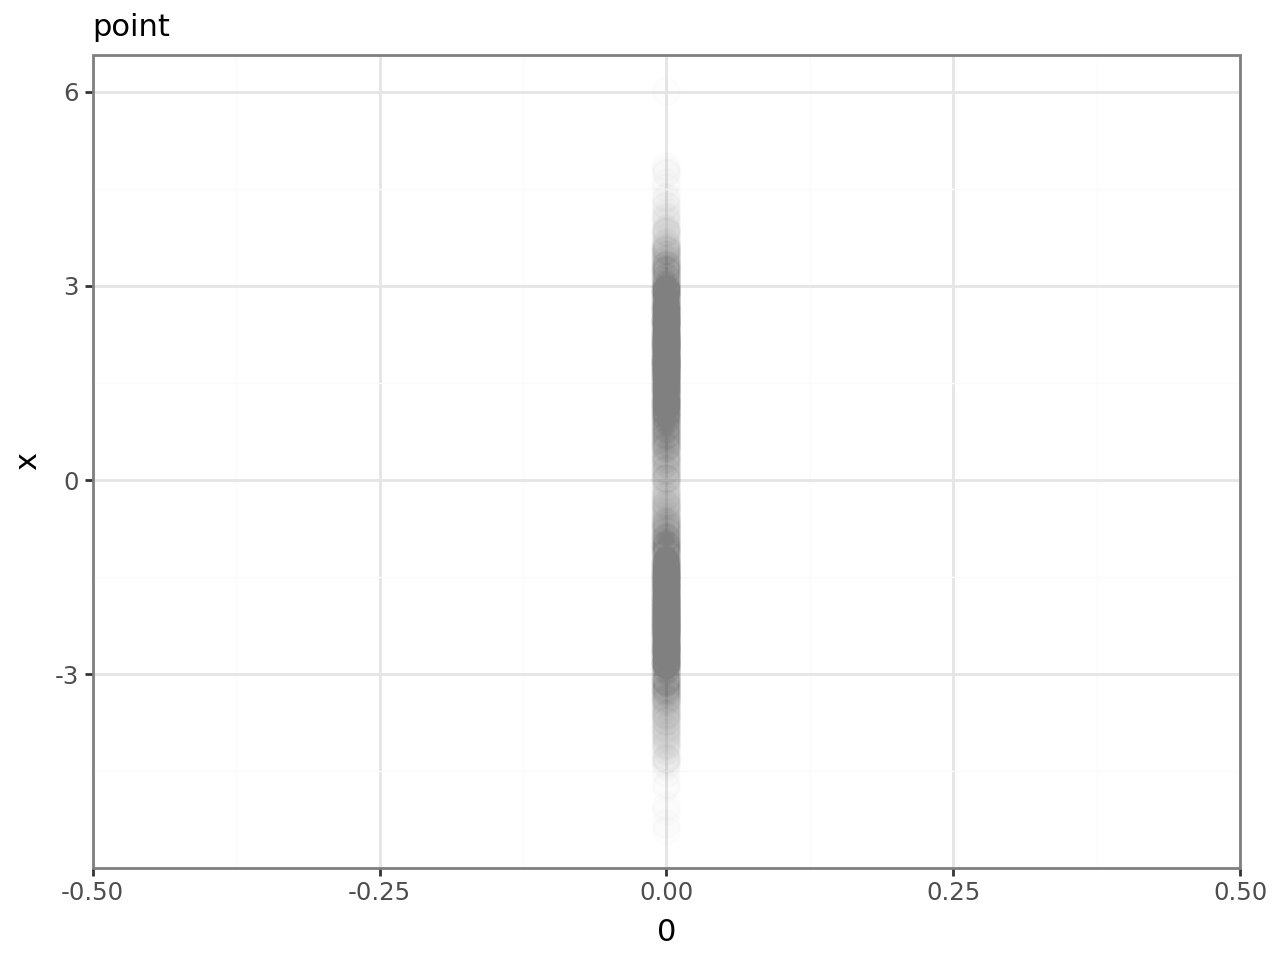

In [6]:
plot2 = plot + p9.coord_flip()
plot2

-----------------------------

### Histogram

We set __bins__ to 40, and set the outer boundary of each bar to be gray


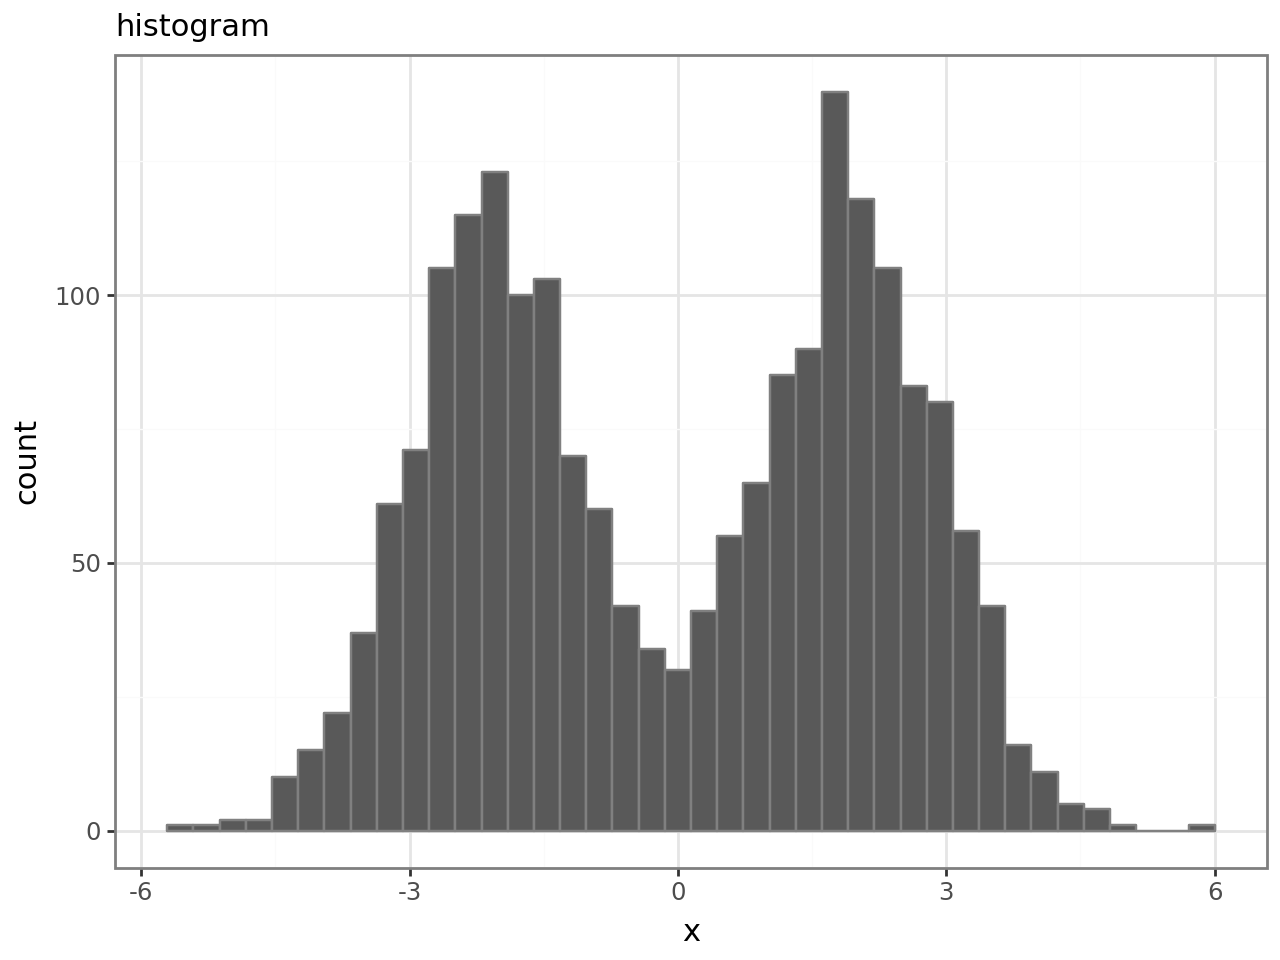

In [7]:
plot3 = (
    p9.ggplot(data=df)
    + p9.geom_histogram(
        mapping=p9.aes(x="x"),
        color="gray",
        bins=40,
    )
    + p9.theme_bw()
    + p9.labs(subtitle="histogram")
)
plot3

Flip axis to get a vertical graphic

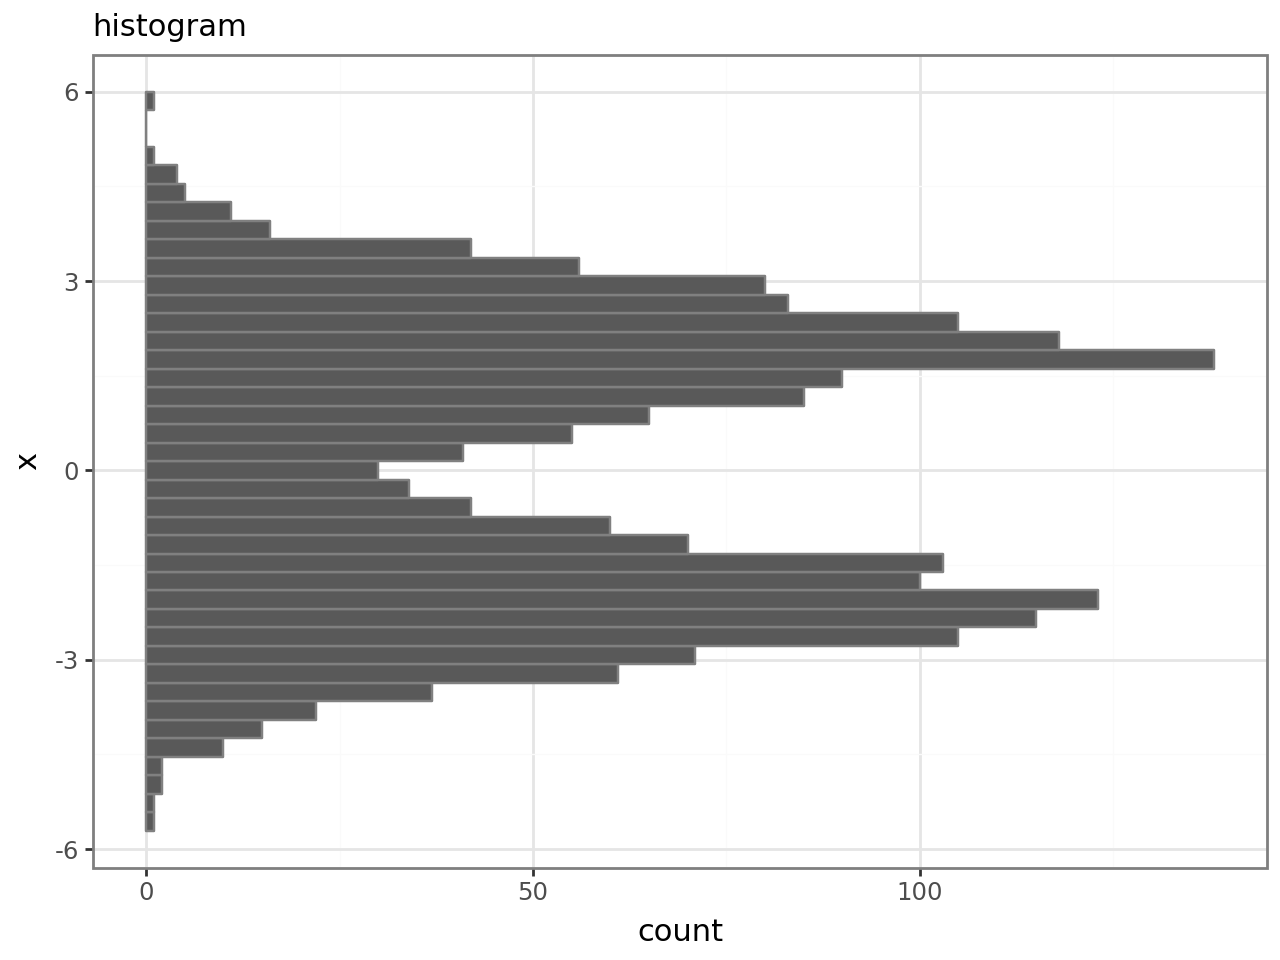

In [8]:
plot4 = plot3 + p9.coord_flip()
plot4

-----------------------------

### sina

This is a specialized graphic, similar to violin plots. It produces a density curve, filled with random jittered dots.

__p9.scale_fill_identity()__ says treat the _fill_ variable as a color name, not as some discrete value.

The x axis labels and tick marks aren't very meaningful, so they are removed

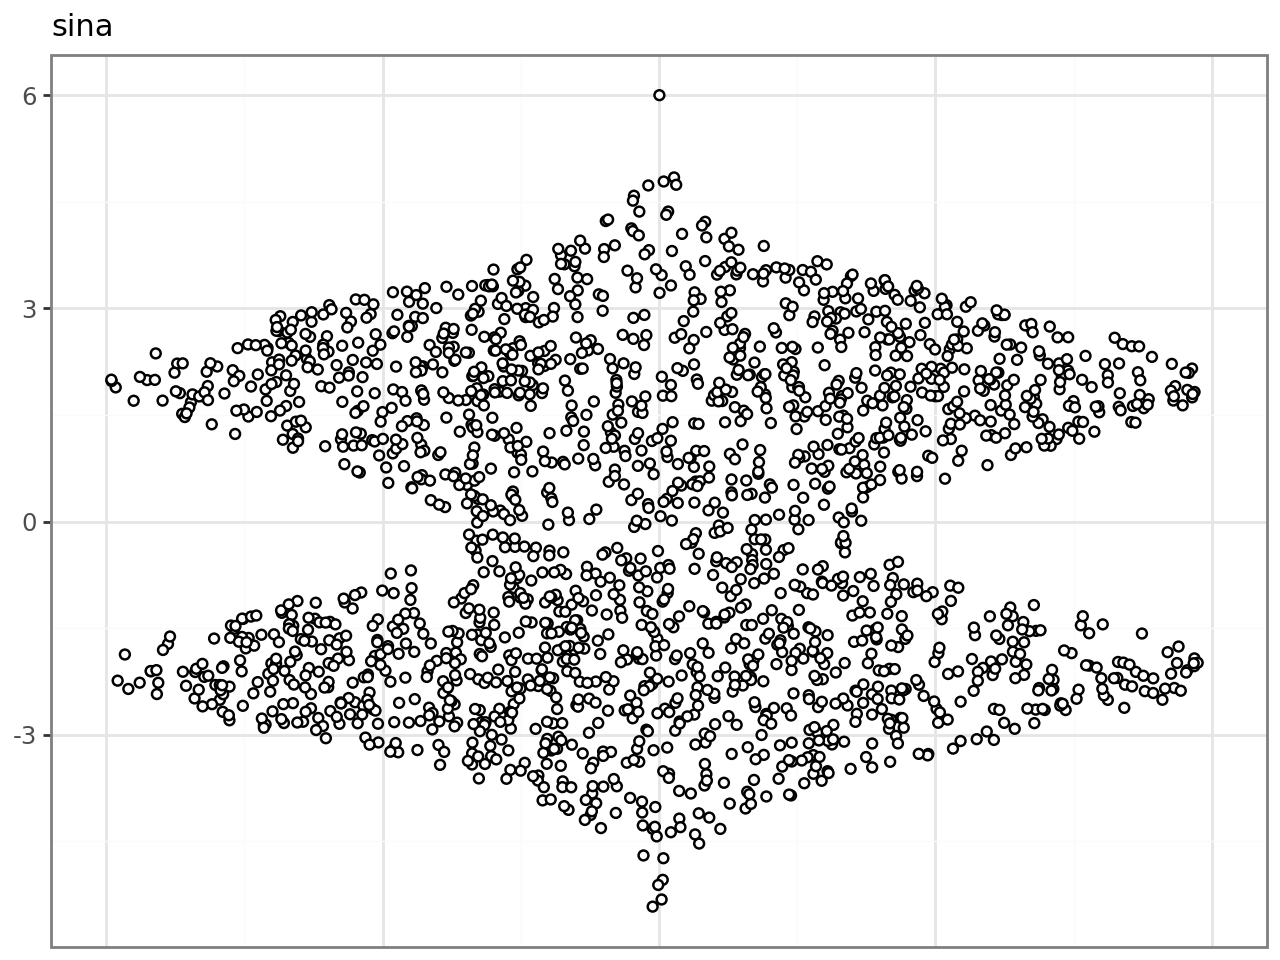

In [9]:
plot5 = (
    p9.ggplot(data=df)
    + p9.geom_sina(
        mapping=p9.aes(x=0, y=x, fill="fill"),
        maxwidth=0.1,
    )
    + p9.scale_fill_identity()
    + p9.theme_bw()
    + p9.labs(subtitle="sina")
)
plot5 + p9.theme(
    axis_title_x=p9.element_blank(),  # Removes the y-axis title
    axis_text_x=p9.element_blank(),  # Removes the y-axis tick labels
    axis_ticks_x=p9.element_blank(),  # Turns off y-axis ticks
)

Flip axis to get a horizontal graphic  (not used subsequently)

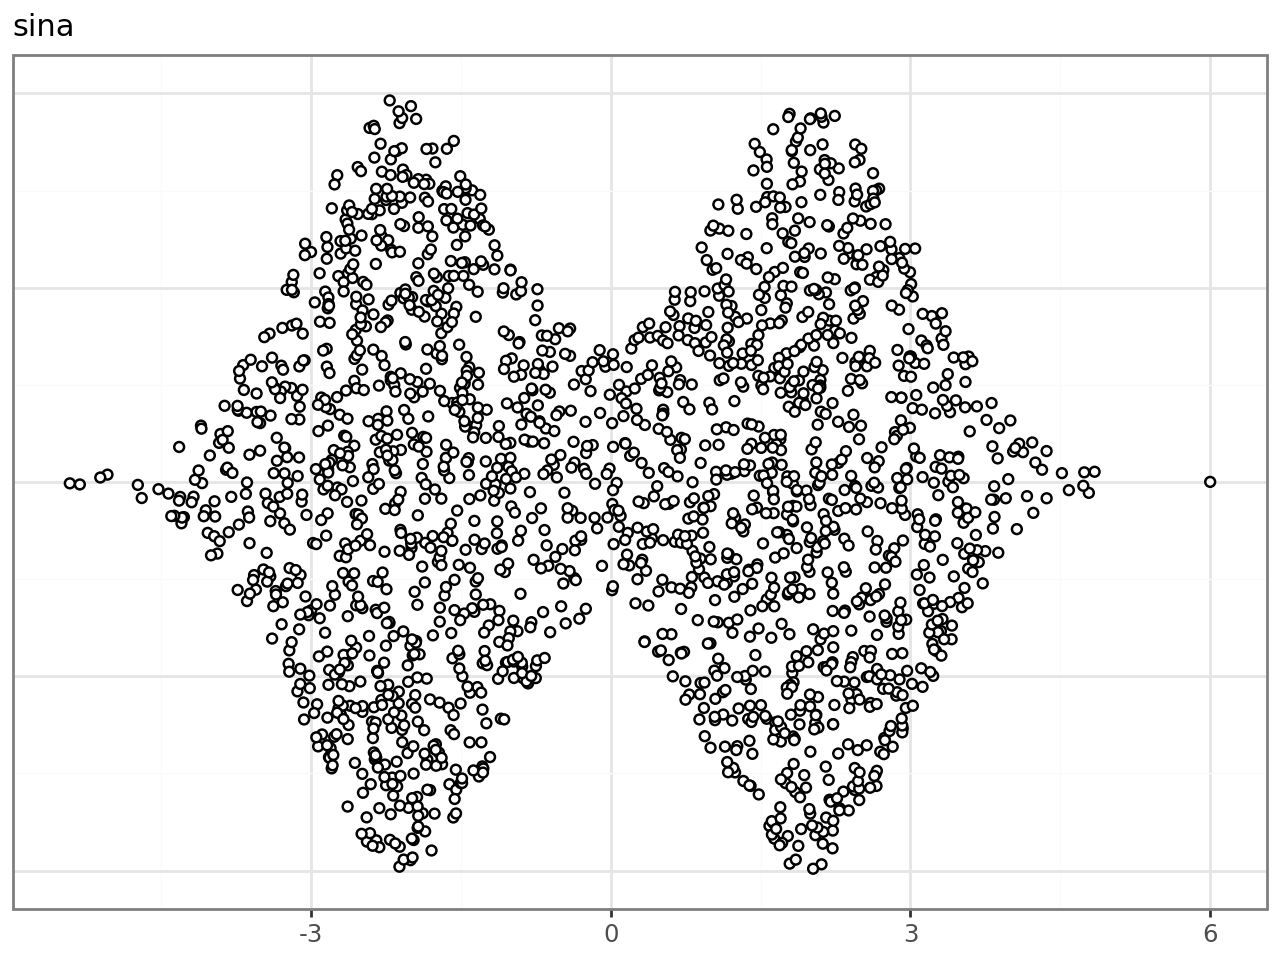

In [10]:
plot6 = (
    plot5
    + p9.coord_flip()
    + p9.theme(
        axis_title_y=p9.element_blank(),  # Removes the y-axis title
        axis_text_y=p9.element_blank(),  # Removes the y-axis tick labels
        axis_ticks_y=p9.element_blank(),  # Turns off y-axis ticks
    )
)
plot6

---------------------

### dotplot

I was very disappointed with __dotplot__.  The y axis seems totally broken - it looks like we get a normalized count (maximum = 1), even though we explicitly ask for a "count"  (and even that is wrong)

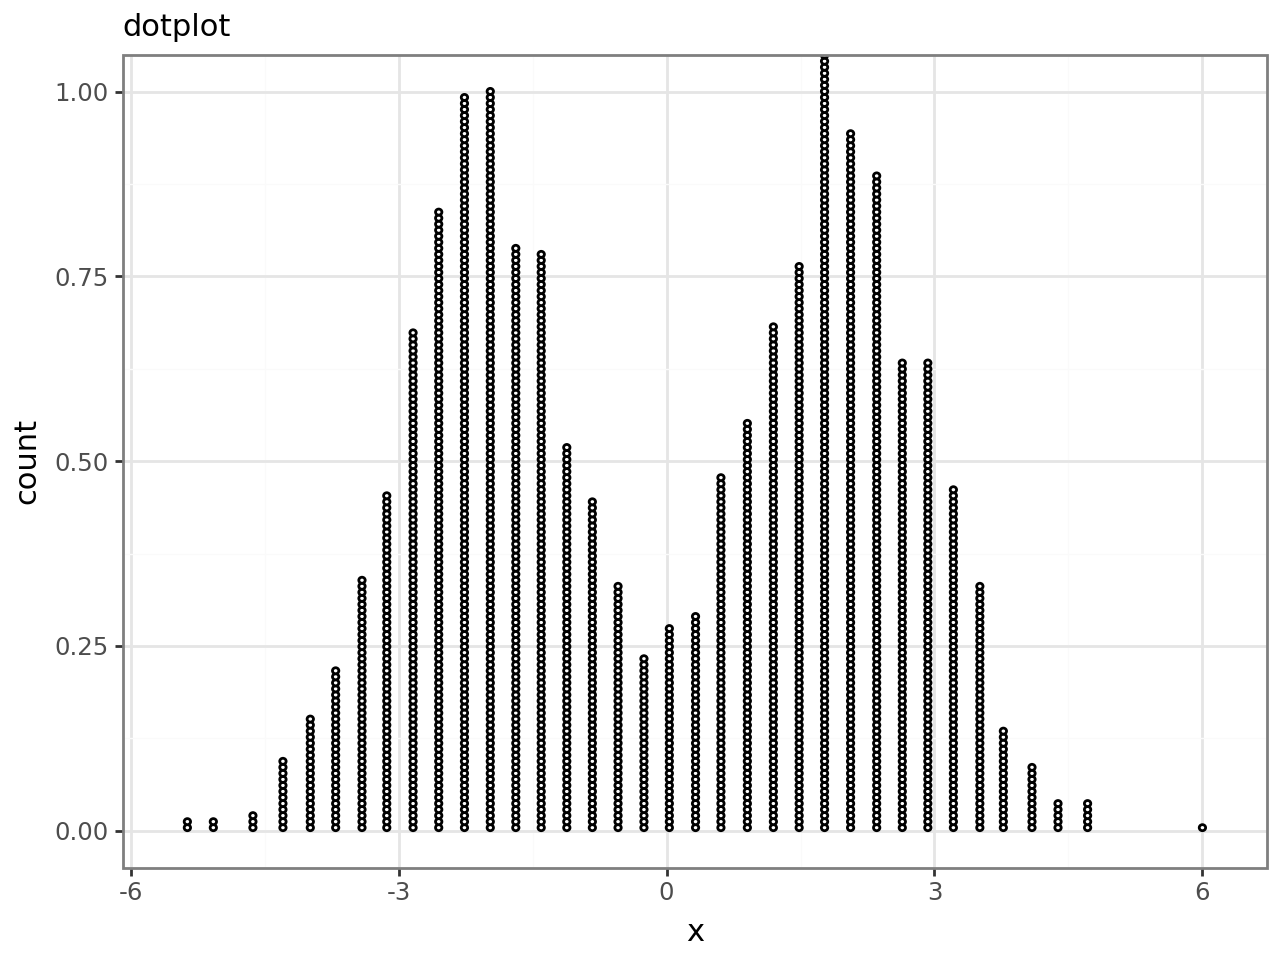

In [11]:
plot7 = (
    p9.ggplot(data=df)
    + p9.geom_dotplot(
        mapping=p9.aes(
            x="x",
            fill="fill",
            y=p9.after_stat("count"),
        ),
        bins=40,
        dotsize=0.25,
    )
    + p9.scale_fill_identity()
    + p9.theme_bw()
    + p9.labs(subtitle="dotplot")
)
plot7

Flip axis to get a vertical graphic fails completely!  I wont be using this in the final graphic.

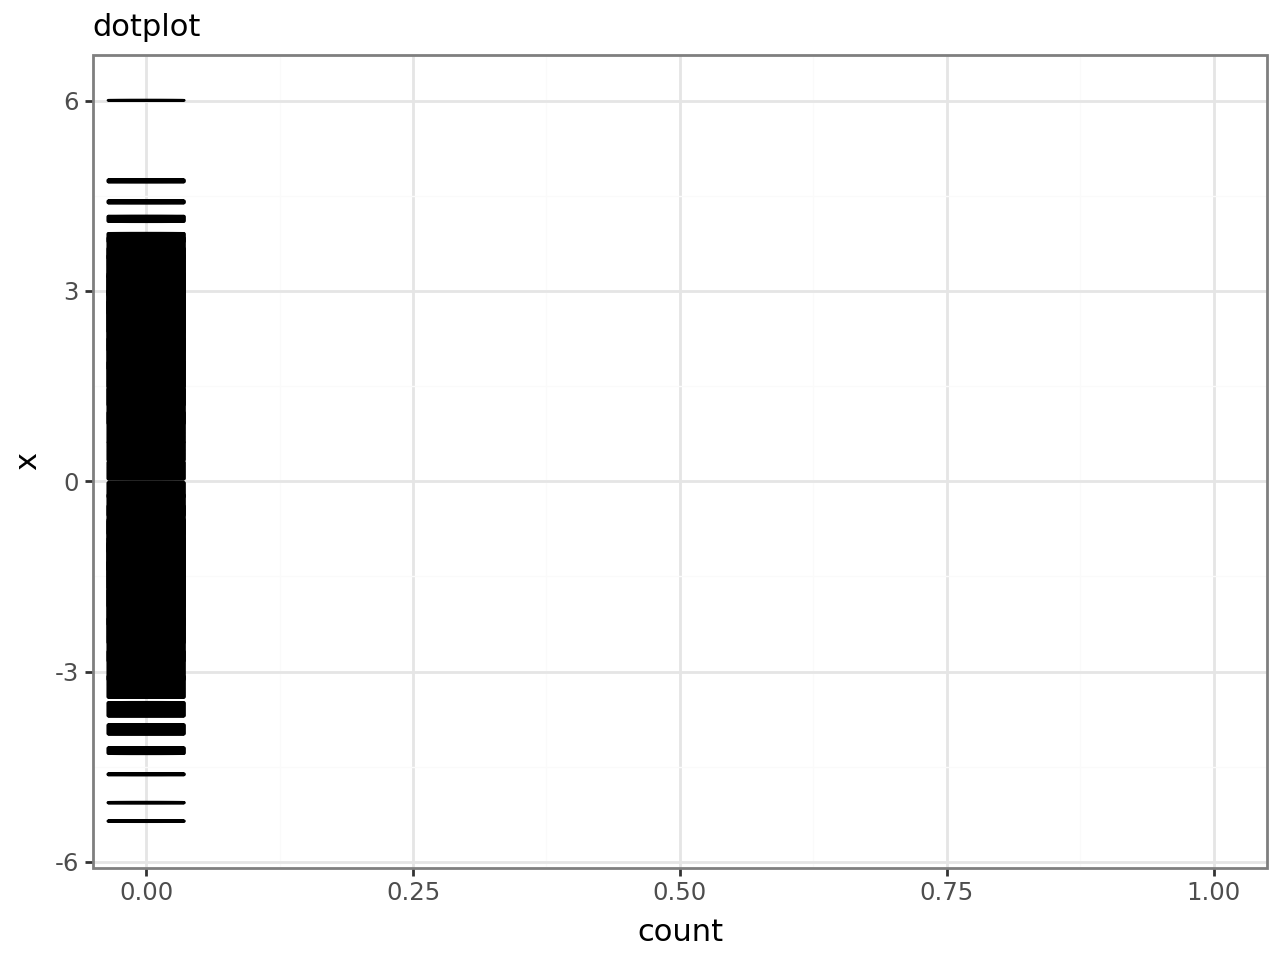

In [12]:
plot8 = plot7 + p9.coord_flip()
plot8

------------------------------

### jitter

In this graphic, we spread the points out to reduce overlap, and plot with a high transparency (low alpha).  The y axis ticks and label aren't neccessary so they are removed

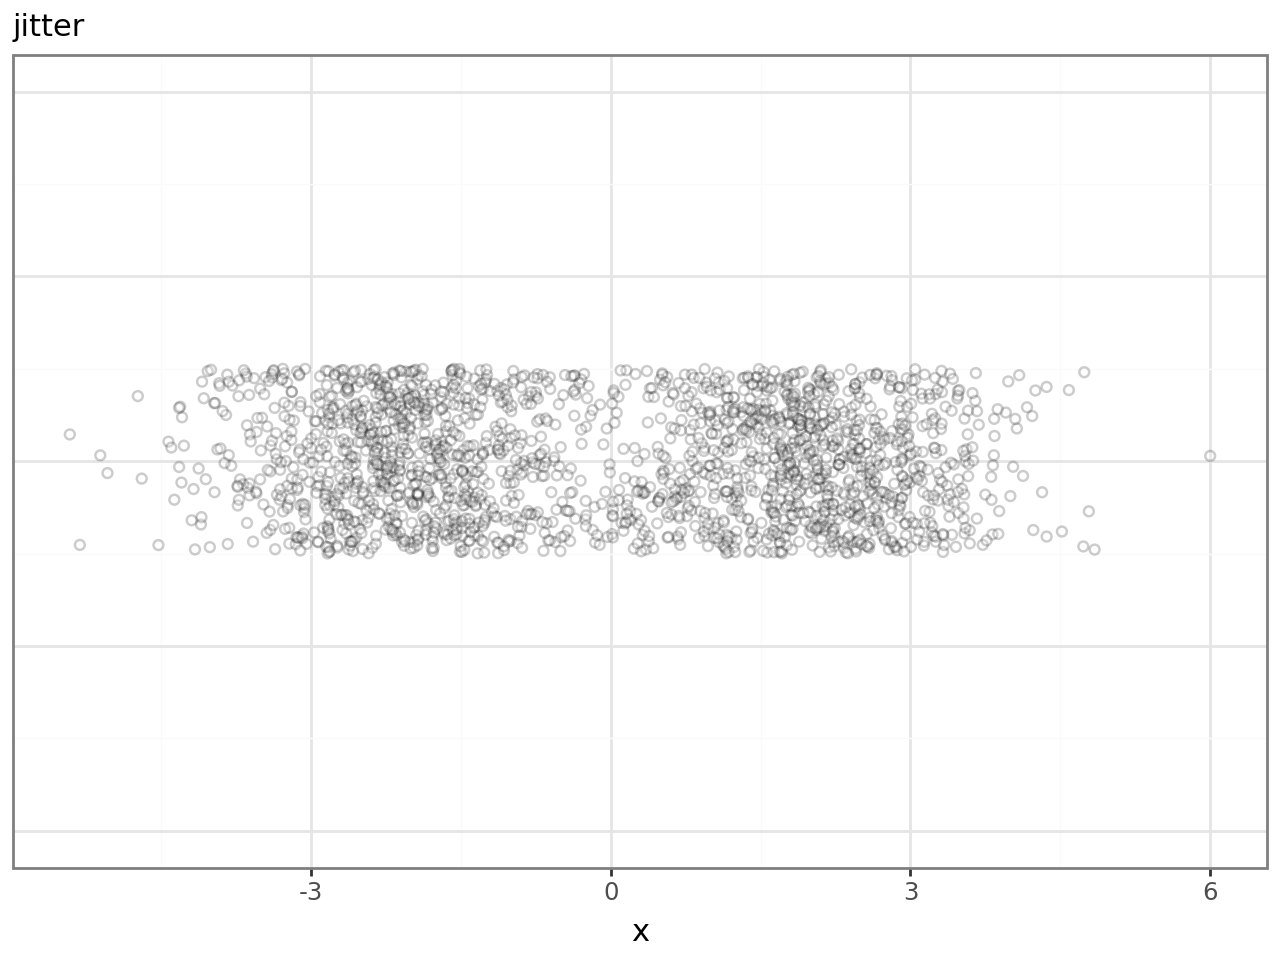

In [13]:
plot9 = (
    p9.ggplot(data=df)
    + p9.geom_jitter(
        mapping=p9.aes(x="x", y=0, fill="fill"),
        width=0,
        height=0.25,
        alpha=0.2,
    )
    + p9.scale_fill_identity()
    + p9.theme_bw()
    + p9.labs(subtitle="jitter")
    + p9.ylim((-1, 1))
)
plot9 + p9.theme(
    axis_title_y=p9.element_blank(),  # Removes the y-axis tick labels
    axis_text_y=p9.element_blank(),  # Removes the y-axis tick labels
    axis_ticks_y=p9.element_blank(),  # Turns off y-axis ticks
    # panel_grid=p9.element_blank(),
)

Flip axis to get a horizontal graphic. We adjust the labels on what is now the x axis

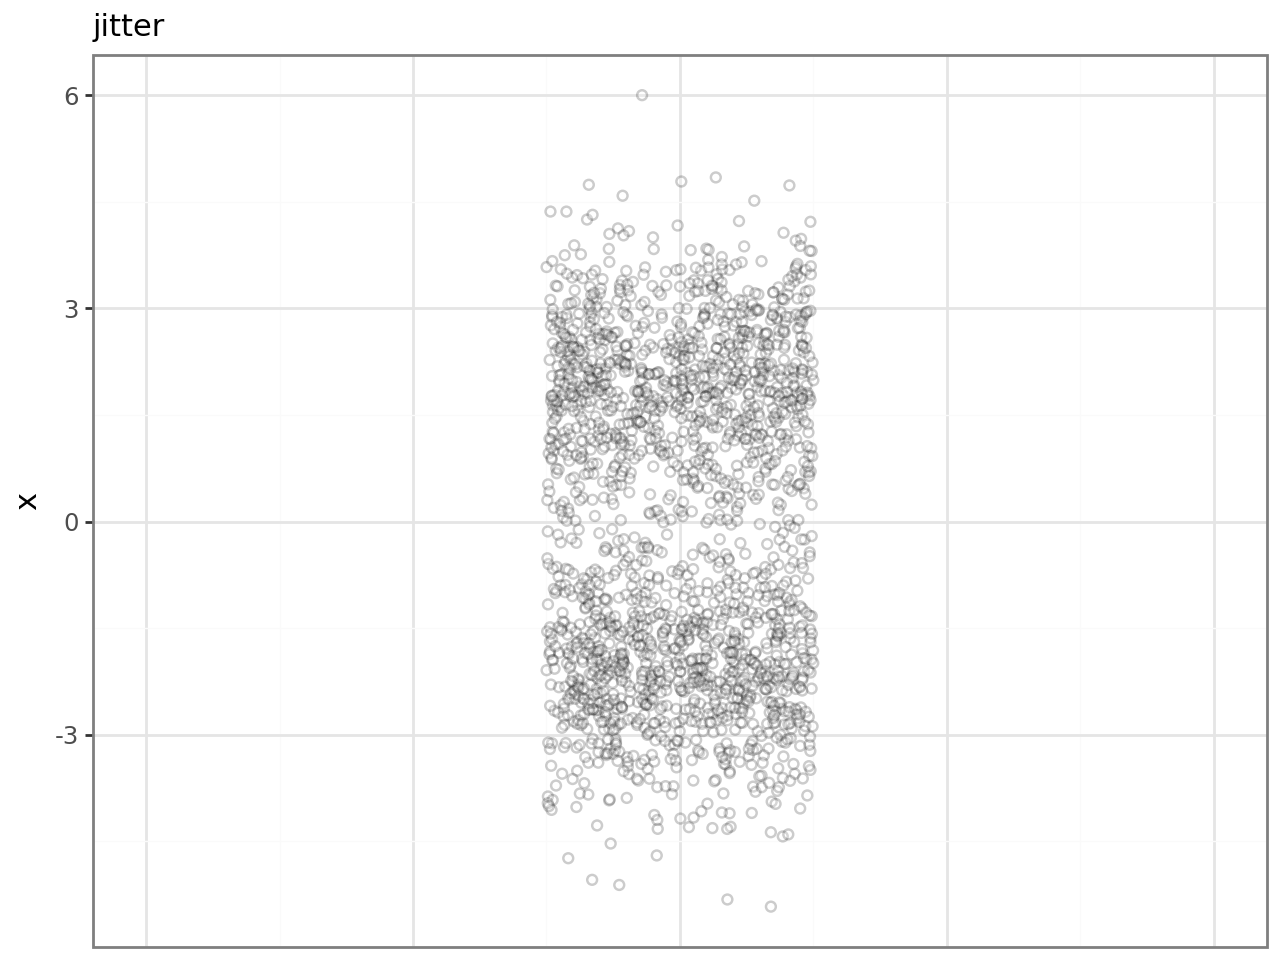

In [14]:
plot10 = plot9 + p9.coord_flip()
plot10 + p9.theme(
    axis_title_x=p9.element_blank(),  # Removes the y-axis tick labels
    axis_text_x=p9.element_blank(),  # Removes the y-axis tick labels
    axis_ticks_x=p9.element_blank(),  # Turns off y-axis ticks
    # panel_grid=p9.element_blank(),
)

--------------------------------

### density

_density_ produces a density curve.  In this, and the two graphics below, we wdd the jittered points for comparison.  One point to note:  because we haven't declared "white" to be a color by the _+ p9.scale_fill_identity()_ call, it gets treated by __geom_jitter__ as a categorical variable, and is allocated the first color in the color map (which happend to be red).  That is why the jittered points have a pink tinge (alpha = 0.05, i.e. very transparent)

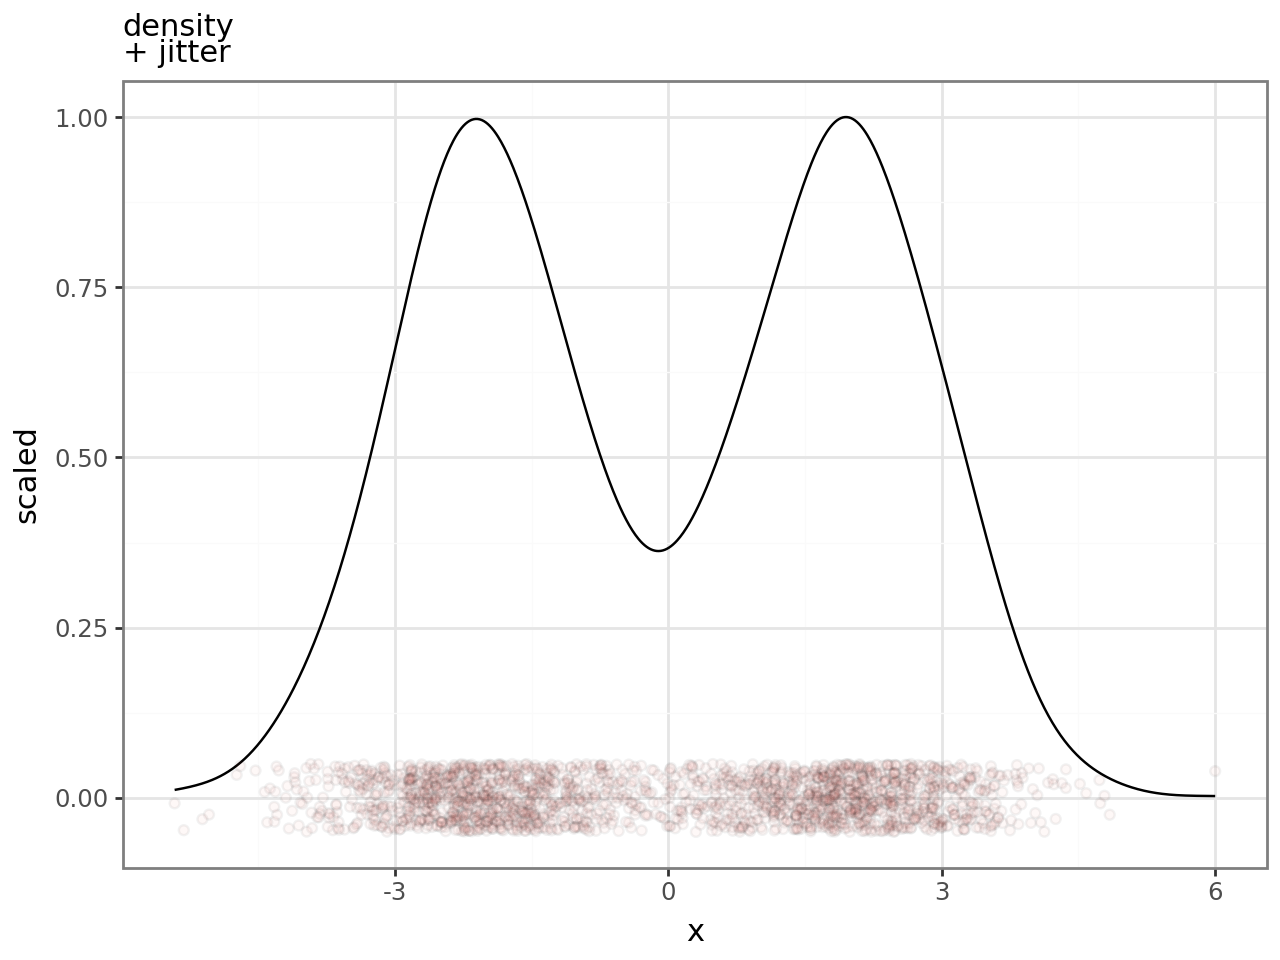

In [15]:
plot11 = (
    p9.ggplot(data=df)
    + p9.geom_density(mapping=p9.aes(x=x, y=p9.stage(start=0, after_stat="scaled")))
    + p9.theme_bw()
    + p9.labs(subtitle="density\n+ jitter")
    + p9.geom_jitter(
        mapping=p9.aes(x="x", y=0, fill="fill"),
        width=0,
        height=0.05,
        alpha=0.05,
        show_legend=False,
    )
)
plot11

Reset the jittered points to be white filled

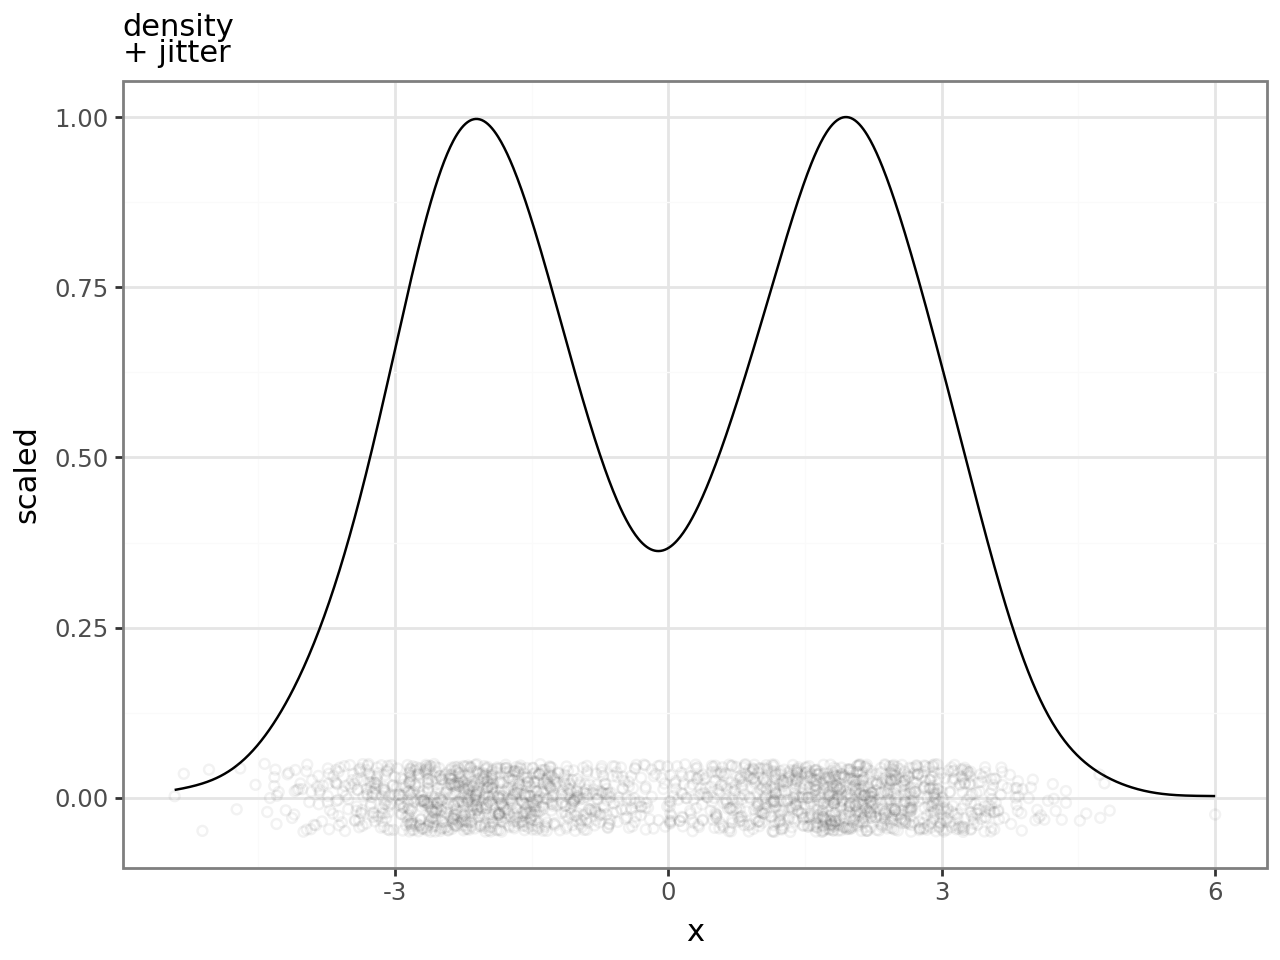

In [16]:
plot11 + p9.scale_fill_identity()

Flip axis to get a vertical graphic

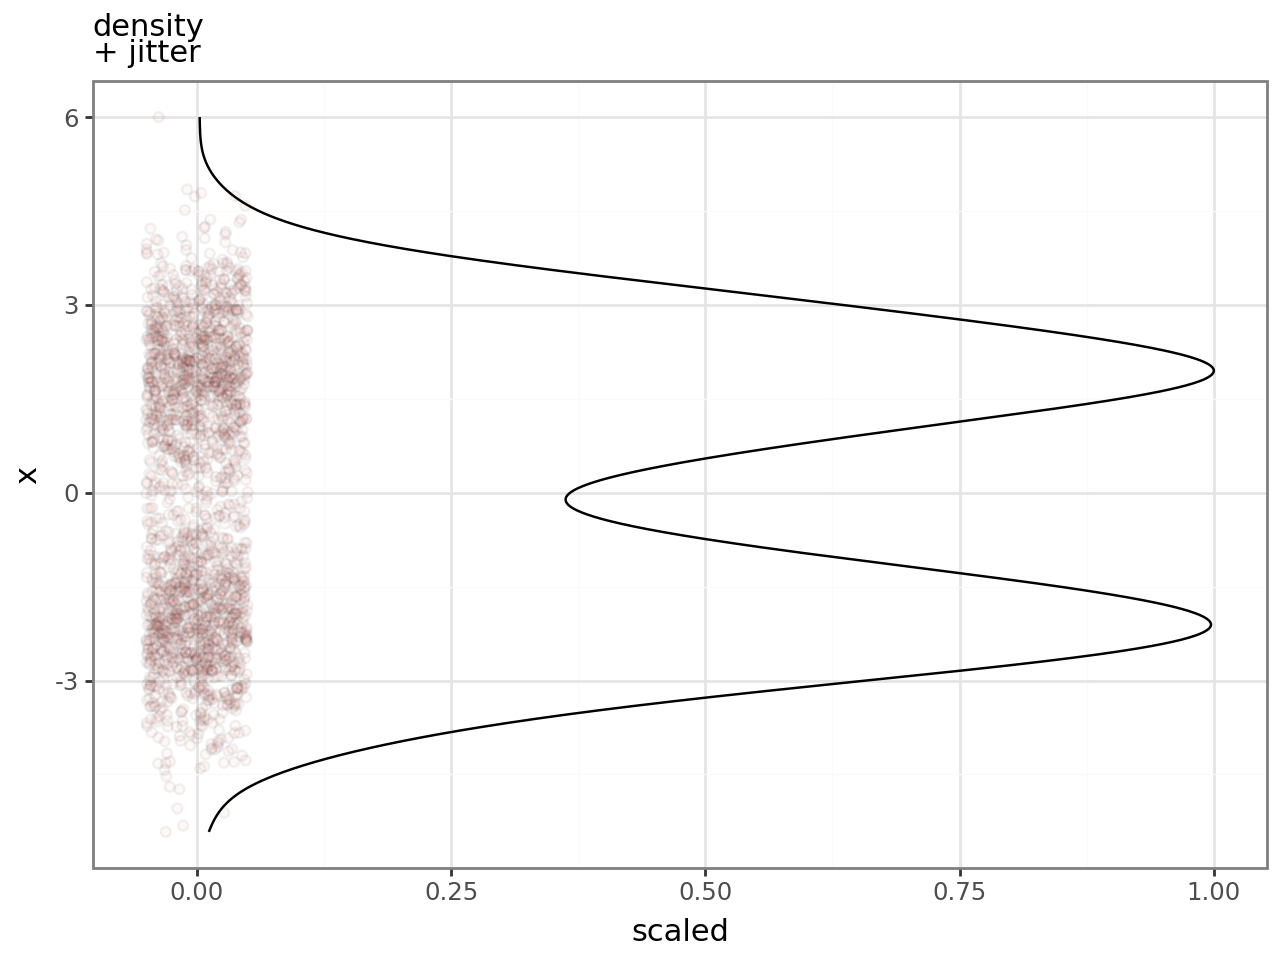

In [17]:
plot12 = plot11 + p9.coord_flip()
plot12

-------------------------

### violin

Violin plots are another way of looking at density curves.  They default to being drawn as vertical curves

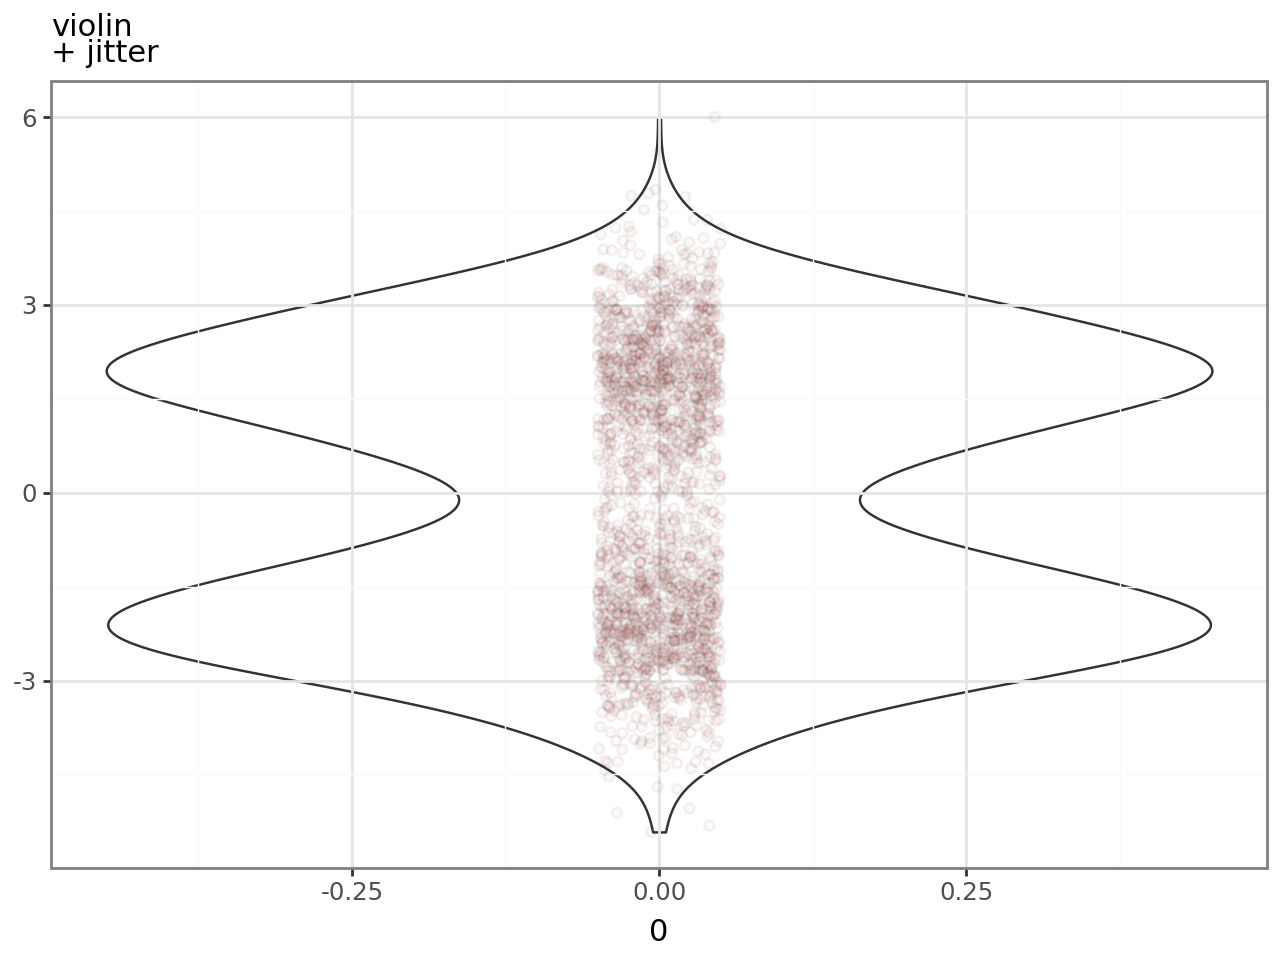

In [18]:
plot13 = (
    p9.ggplot(data=df)
    + p9.geom_violin(
        mapping=p9.aes(y=x),
    )
    + p9.geom_jitter(
        mapping=p9.aes(x=0, y=x, fill="fill"),
        width=0.05,
        height=0,
        alpha=0.05,
        show_legend=False,
    )
    + p9.theme_bw()
    + p9.labs(subtitle="violin\n+ jitter")
)
plot13

Flip axis to get a horizontal graphic  (not used subsequently)

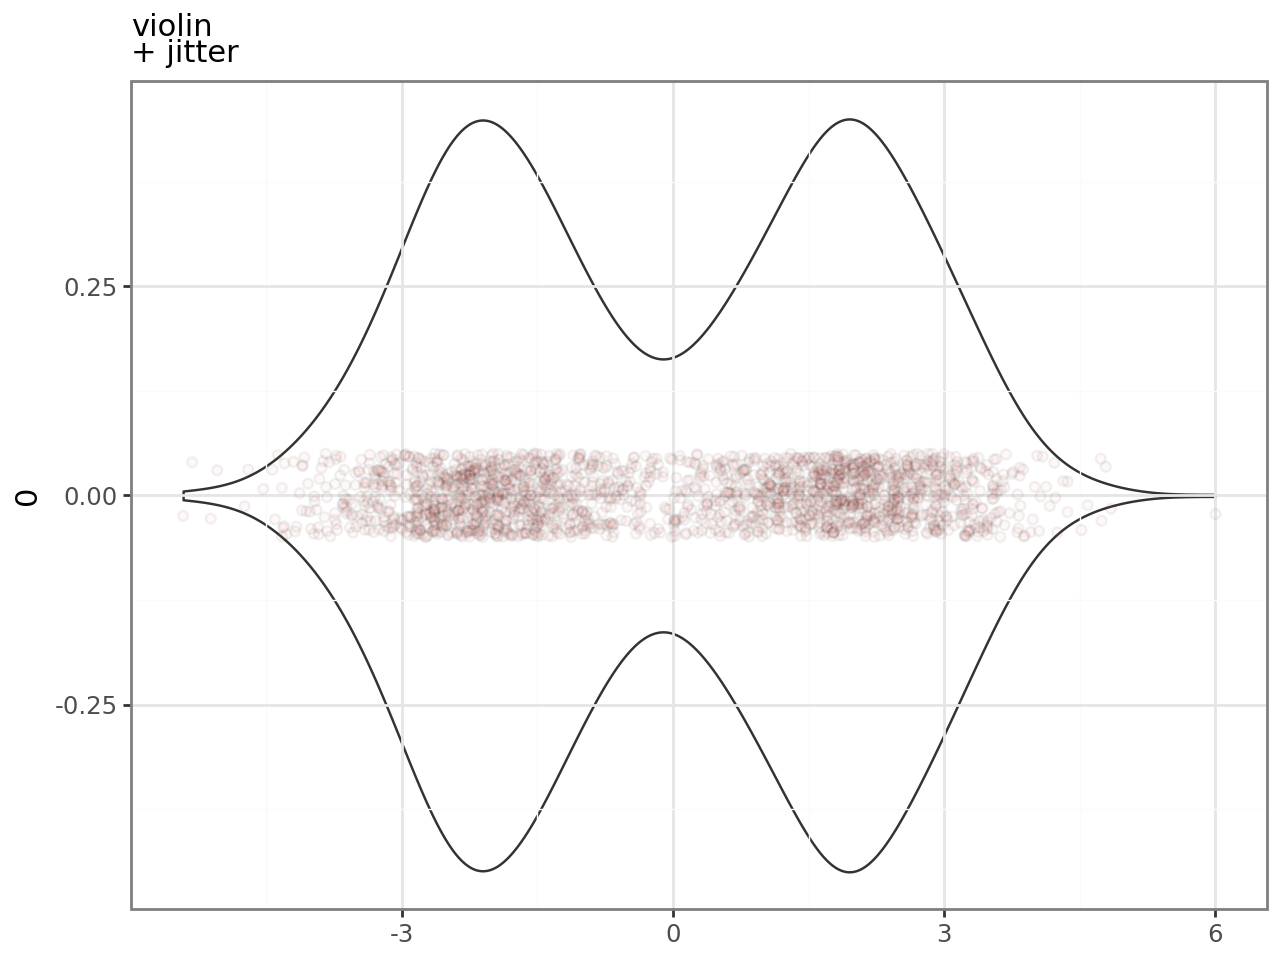

In [19]:
plot14 = plot13 + p9.coord_flip()
plot14

--------------------------

### boxplot

I am not a big fan of boxplots.  They are hard to understand, and as can be seen below, they can give a completely incorrect impression as to density distribution

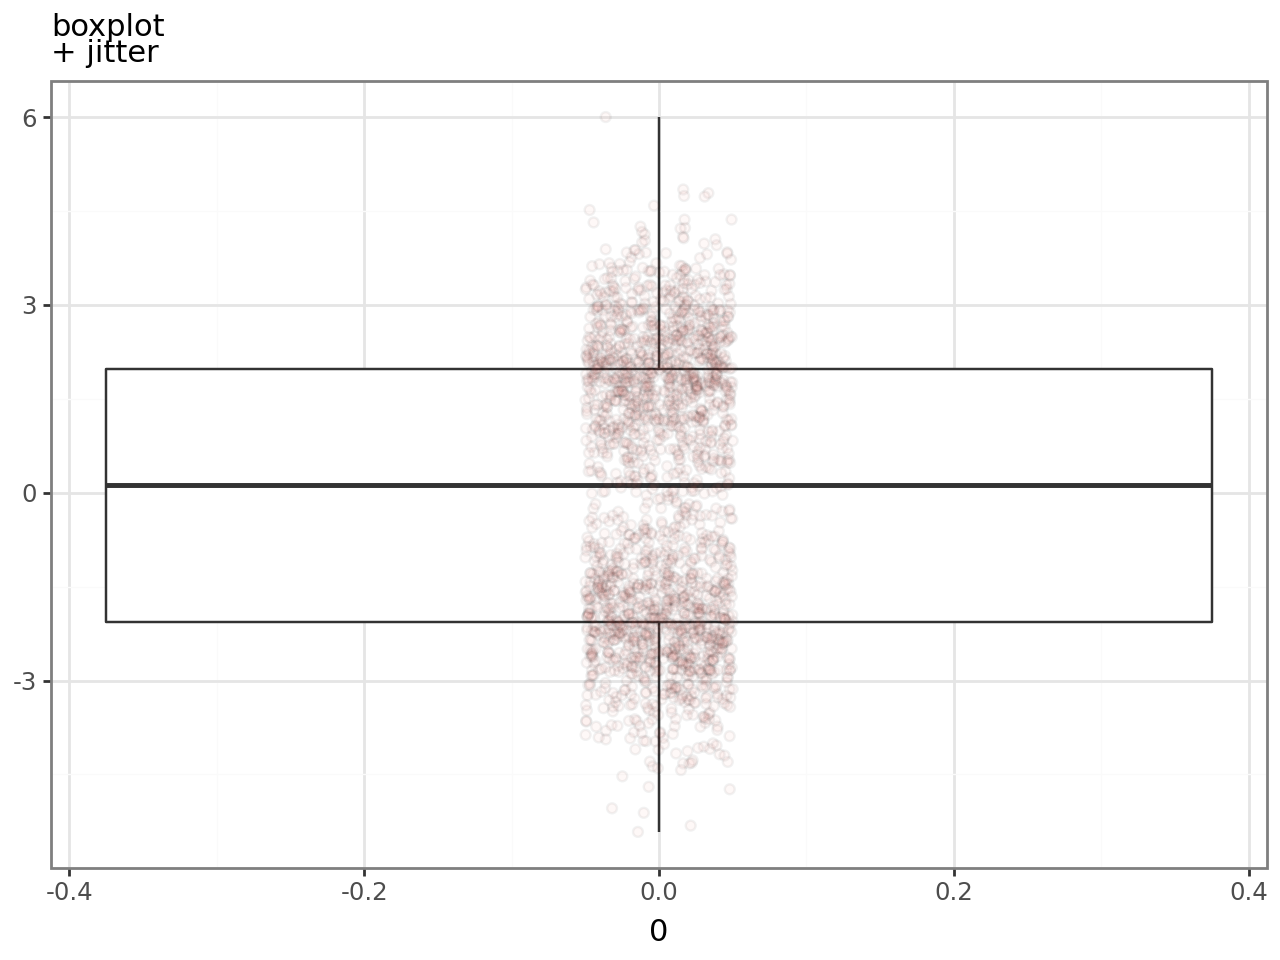

In [20]:
plot15 = (
    p9.ggplot(data=df)
    + p9.geom_boxplot(
        mapping=p9.aes(y=x, x=0),
    )
    + p9.geom_jitter(
        mapping=p9.aes(x=0, y=x, fill="fill"),
        width=0.05,
        height=0,
        alpha=0.05,
        show_legend=False,
    )
    + p9.theme_bw()
    + p9.labs(subtitle="boxplot\n+ jitter")
)
plot15

Flip axis to get a horizontal graphic  (not used subsequently)

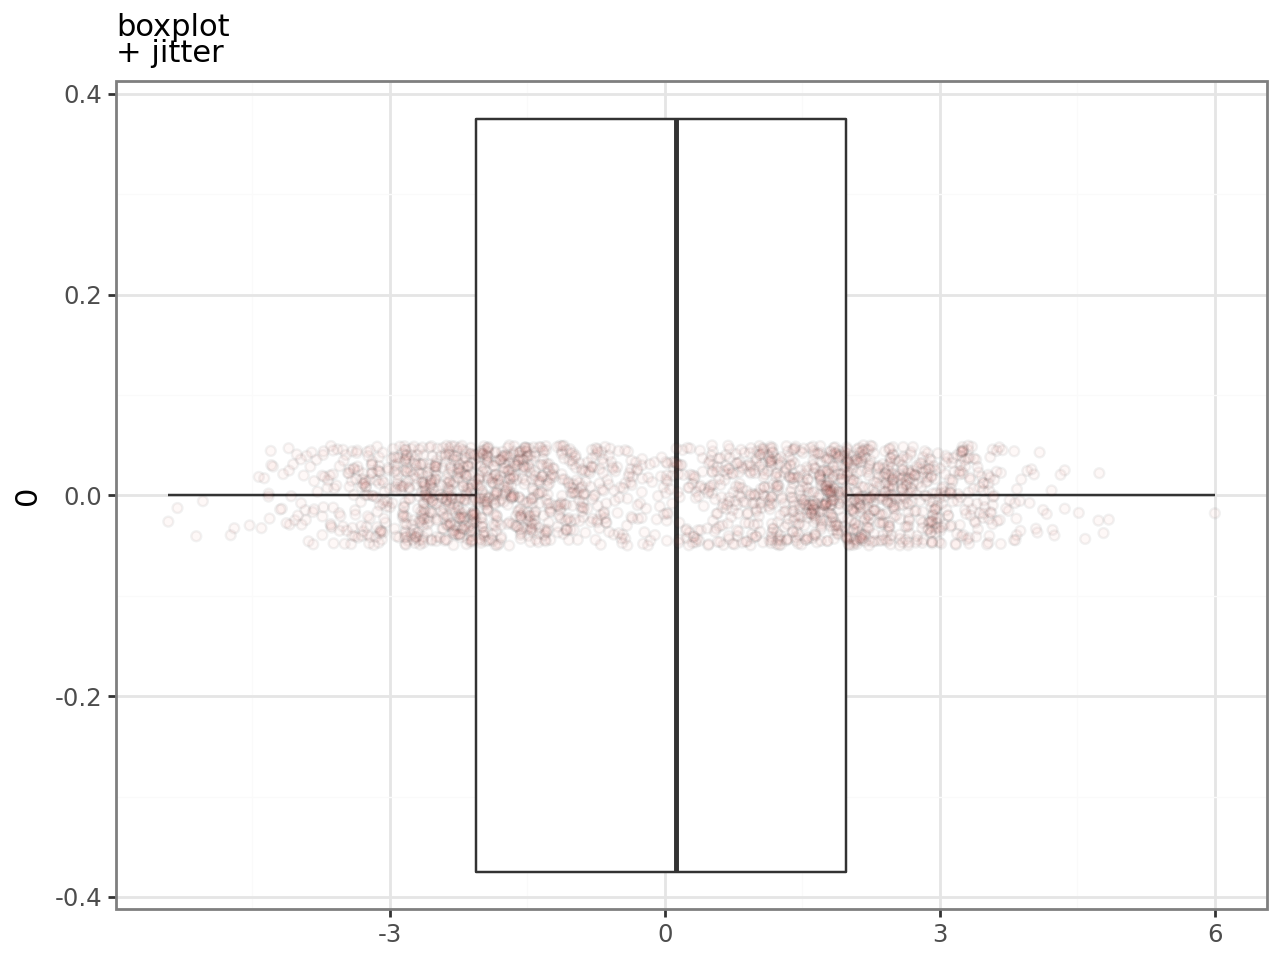

In [21]:
plot16 = plot15 + p9.coord_flip()
plot16

----------------------

### sina (again)

Because we will be compressing plots in the x direction, we reduce the default transparency of the random poinrs, and their size

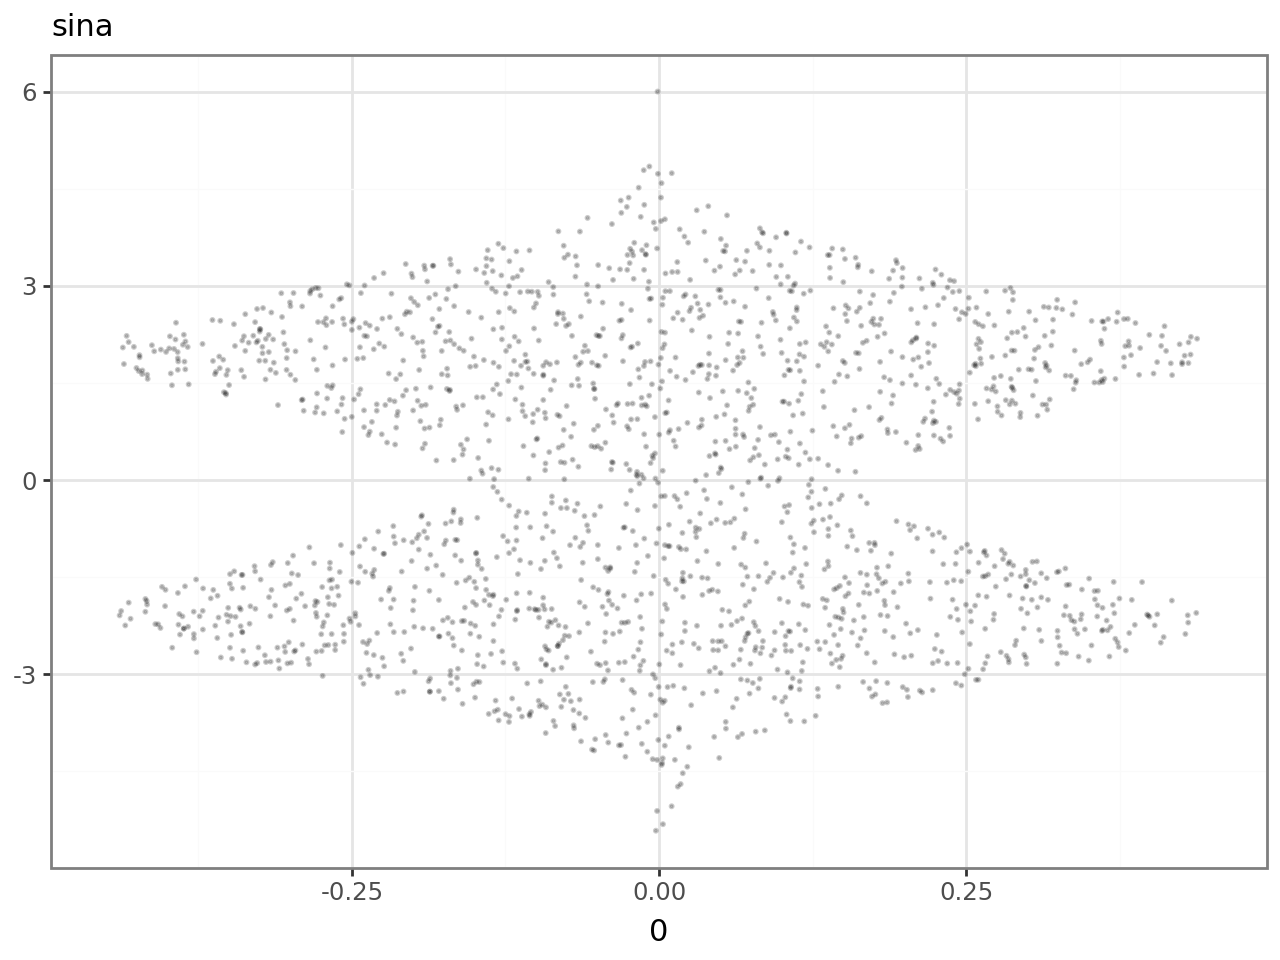

In [22]:
plot17 = (
    p9.ggplot(data=df)
    + p9.geom_sina(
        mapping=p9.aes(y=x, x=0),
        alpha=0.2,
        size=0.2,
    )
    + p9.theme_bw()
    + p9.labs(subtitle="sina")
)
plot17

---------------------------------

### Final composite graphic

First of all we tidy up the y axis titles (where not needed)

In [23]:
plot4 = plot4 + p9.theme(
    axis_title_y=p9.element_blank(),
)  # Removes the y-axis title)

plot10 = plot10 + p9.theme(
    axis_title_y=p9.element_blank(),
)  # Removes the y-axis title)

plot12 = plot12 + p9.theme(
    axis_title_y=p9.element_blank(),
)  # Removes the y-axis title)

plot17 = plot17 + p9.theme(
    axis_title_x=p9.element_blank(),
)  # Removes the y-axis title)

We put a title on the left-most plot, which will act as the overall title.  Titles for compositions are coming to plotnine, but not just yet.

We build the composition, and tidy up the x axis, which we want unadorned

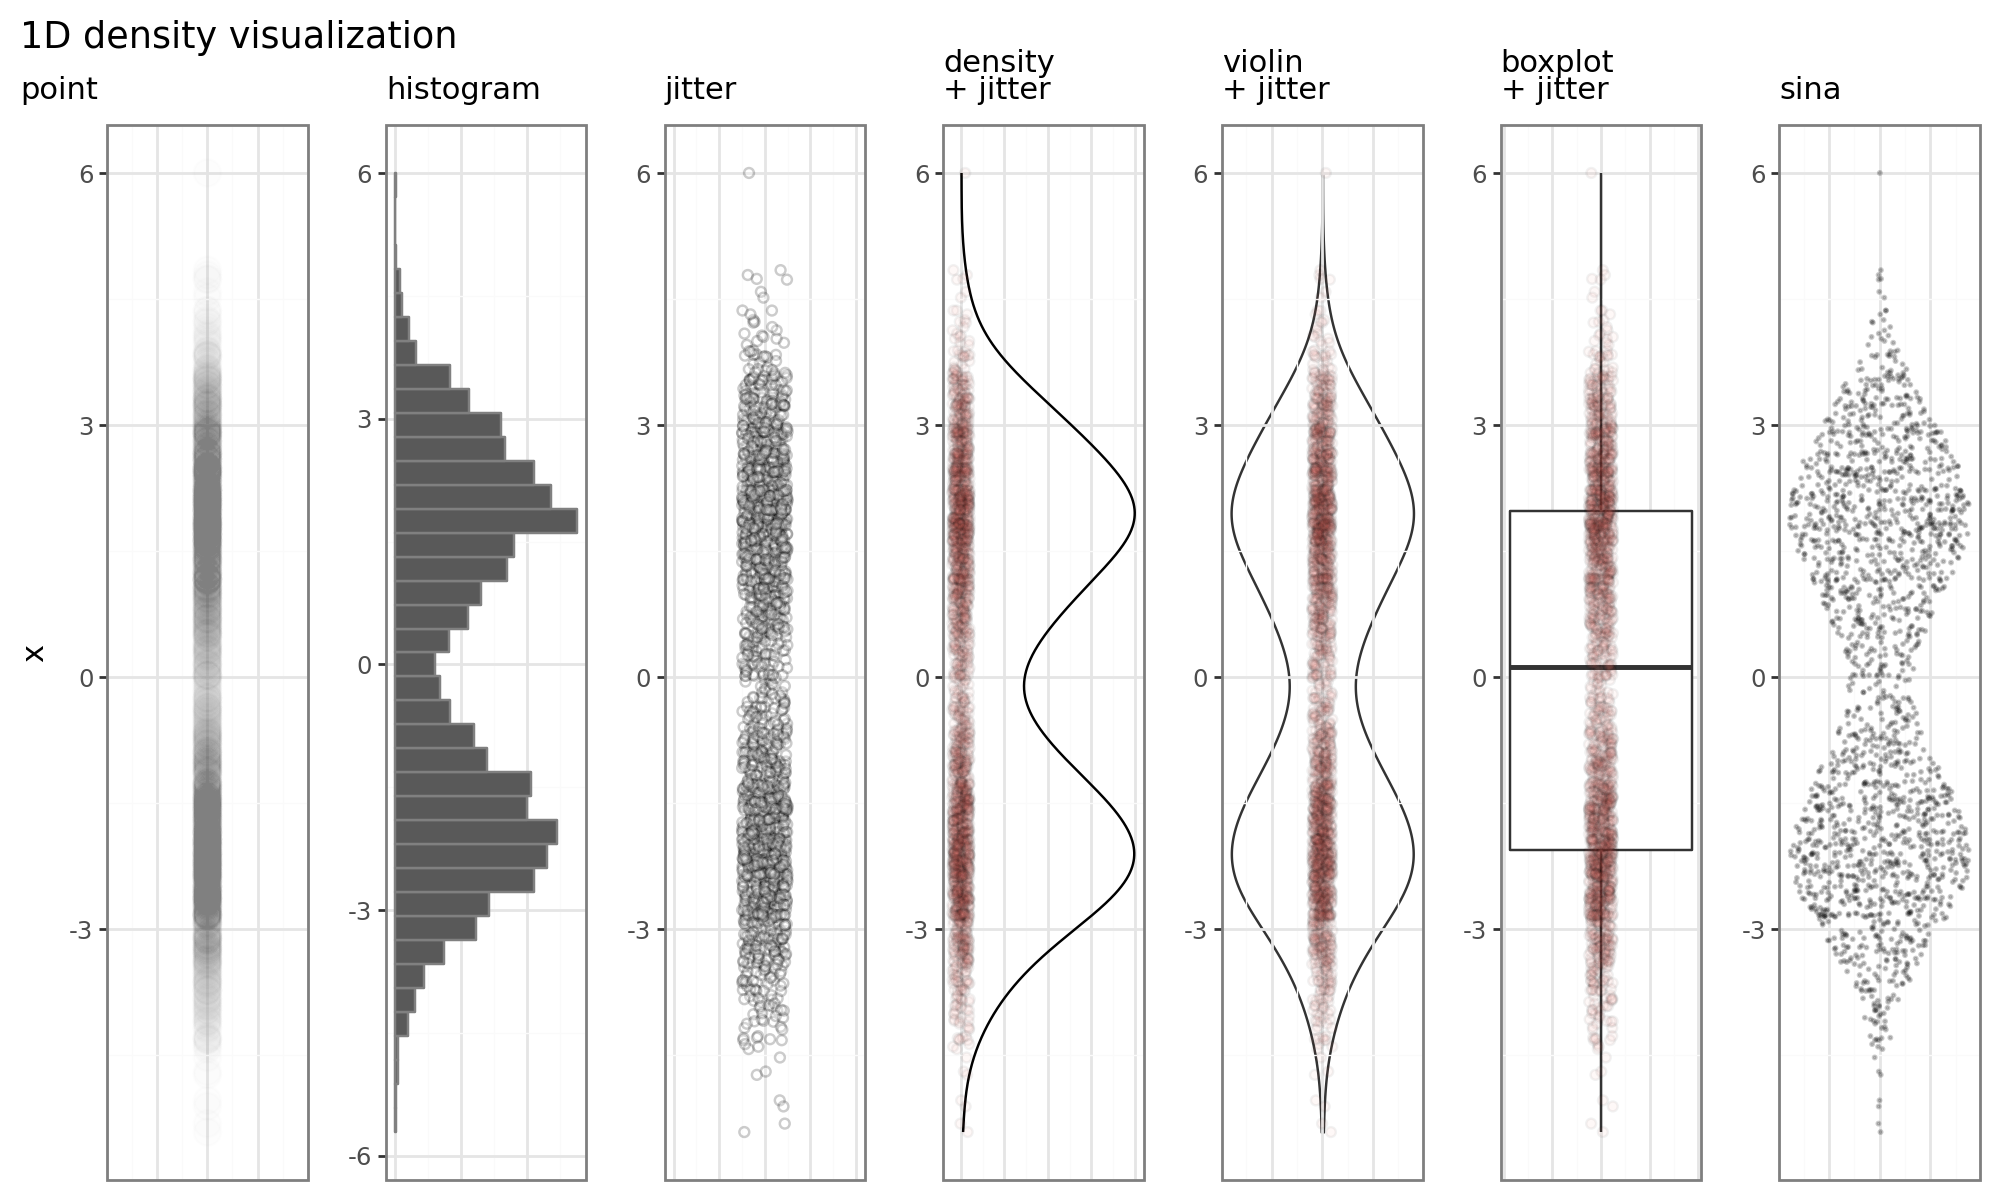

In [24]:
plot2 = (
    plot2
    + p9.labs(title="1D density visualization")
    + p9.theme(plot_title_position="plot")
)

(plot2 | plot4 | plot10 | plot12 | plot13 | plot15 | plot17) * p9.theme(
    figure_size=(10, 6),
    axis_title_x=p9.element_blank(),  # Removes the x-axis title
    axis_text_x=p9.element_blank(),  # Removes the x-axis tick labels
    axis_ticks_x=p9.element_blank(),  # Turns off x-axis ticks
    # panel_grid=p9.element_blank(),
)

----------------------

## Conclusions

This demonstrates the minimal code needed for a quiet nice graphic.  Plotnine defaults are really very well chosen in my experience.

Also, steer clear of _dotplot_, and refrain from _boxplots_

------------------------

## Reproducability

In [25]:
%watermark

Last updated: 2026-03-09T16:15:37.002049+10:00

Python implementation: CPython
Python version       : 3.11.14
IPython version      : 9.10.0

Compiler    : MSC v.1929 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 170 Stepping 4, GenuineIntel
CPU cores   : 22
Architecture: 64bit



In [26]:
%watermark -h -iv -co

conda environment: fun_minim

Hostname: INSPIRON16

numpy   : 2.4.1
pandas  : 2.3.3
plotnine: 0.15.0



In [27]:
import contextlib

import ipynbname

with contextlib.suppress(FileNotFoundError):
    print(f"Notebook file name: {ipynbname.name()}")
# end with

Notebook file name: one_d_density
